# Figures for the lecture notes

Makes the HANC figures of `lecture-notes-ha.md` and saves them to `figs/notes/`.
The model and the code are those of `02-Transition-Manually-PE.ipynb` to `05-Fake-News-Algorithm.ipynb`, annual calibration.

## Imports

In [1]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from consav.grids import equilogspace
from consav.markov import log_rouwenhorst
from consav.linear_interp import interp_1d_vec

## Settings

In [2]:
class Parameters:
    def __init__(self):
        # preferences
        self.beta = 0.95
        self.sigma = 1.0

        # production
        self.alpha = 1/3
        self.delta = 0.1/3
        self.Gamma = 1.0

        # grids
        self.Na = 500
        self.a_min = 0.0
        self.a_max = 10_000.0
        self.a_grid = equilogspace(self.a_min,self.a_max,self.Na)

        # income
        self.rho_z = 0.95
        self.sigma_psi = 0.30*(1.0-self.rho_z**2.0)**0.5
        self.Nz = 7
        self.z_grid, self.z_trans,self.z_ergodic,_,_ = log_rouwenhorst(self.rho_z,self.sigma_psi,self.Nz)

par = Parameters()

# targets
r_ss = 0.05
Y_ss = 1.0
K_ss = 4.0

# transition
T = 300
h = 1e-4

plt.rcParams.update({'font.size':12,'axes.spines.top':False,'axes.spines.right':False})

## Household block

In [3]:
def solve_hh_backwards_one_step(z_trans, z_grid, a_grid, sigma, beta, r, w, vbeg_a):
    """One EGM step."""

    Nz, Na = vbeg_a.shape
    a = np.zeros((Nz, Na))
    c = np.zeros((Nz, Na))

    # a. solve step
    for i_z in range(Nz):

        # i. consumption and cash-on-hand on the endogenous grid
        c_endo = (beta*vbeg_a[i_z])**(-1/sigma)
        m_endo = c_endo + a_grid

        # ii. interpolation to the fixed grid
        m = (1+r)*a_grid + w*z_grid[i_z]
        interp_1d_vec(m_endo,a_grid,m,a[i_z])
        a[i_z,:] = np.fmax(a[i_z,:],0.0)
        c[i_z] = m-a[i_z]

    # b. expectation step
    vbeg_a_new = z_trans @ ((1+r)*c**(-sigma))

    return c, a, vbeg_a_new

def egm_ss(r, w, par, max_iter=50_000, tol=1e-12):
    """Iterate the EGM step to the steady state."""

    c = r*par.a_grid[np.newaxis,:] + w*par.z_grid[:,np.newaxis]
    vbeg_a = (1+r)*c**(-par.sigma)
    for it in range(max_iter):
        c, a, vbeg_a_new = solve_hh_backwards_one_step(par.z_trans, par.z_grid, par.a_grid, par.sigma, par.beta, r, w, vbeg_a)
        if np.max(np.abs(vbeg_a_new-vbeg_a)) < tol:
            return c, a, vbeg_a_new
        vbeg_a = vbeg_a_new

def get_lottery(a, a_grid):
    """Lottery indices and weights on the lower gridpoint."""

    a_i = np.searchsorted(a_grid, a, side='right') - 1
    a_i = np.clip(a_i, 0, len(a_grid)-2)
    a_pi = (a_grid[a_i+1] - a)/(a_grid[a_i+1] - a_grid[a_i])
    return a_i, a_pi

@nb.njit
def forward_iteration(D, z_trans, a_i, a_pi):
    """One histogram step: savings lottery, then productivity transition."""

    Dend = np.zeros_like(D)
    for i_z in range(a_i.shape[0]):
        for i_a in range(a_i.shape[1]):
            Dend[i_z, a_i[i_z,i_a]] += a_pi[i_z,i_a]*D[i_z,i_a]
            Dend[i_z, a_i[i_z,i_a]+1] += (1-a_pi[i_z,i_a])*D[i_z,i_a]
    return z_trans.T @ Dend

def distribution_ss(a, par, tol=1e-10):
    """Iterate the histogram step to the stationary distribution."""

    a_i, a_pi = get_lottery(a, par.a_grid)
    D = par.z_ergodic[:,np.newaxis]*np.ones_like(par.a_grid)/par.Na
    for _ in range(100_000):
        D_new = forward_iteration(D, par.z_trans, a_i, a_pi)
        if np.max(np.abs(D_new-D)) < tol:
            return D_new
        D = D_new

def household_ss(r, w, par):
    """Steady-state policies, distribution and aggregates."""

    c, a, vbeg_a = egm_ss(r, w, par)
    D = distribution_ss(a, par)
    return np.sum(D*a), np.sum(D*c), D, a, c, vbeg_a

@nb.njit
def forward_iteration_trans(D_init, z_trans, a_i, a_pi, T):
    """Histogram steps along a transition."""

    Nz, Na = D_init.shape
    D = np.zeros((T, Nz, Na))
    D[0] = D_init
    for t in range(T-1):
        D[t+1] = forward_iteration(D[t], z_trans, a_i[t], a_pi[t])
    return D

def get_impulse_response(vbeg_a_term, D_init, r_vec, w_vec, par):
    """Household impulse response to a price path."""

    T = r_vec.size

    # a. backward step
    a_trans = np.zeros((T, par.Nz, par.Na))
    c_trans = np.zeros((T, par.Nz, par.Na))
    vbeg_a = vbeg_a_term.copy()
    for t in reversed(range(T)):
        c_trans[t], a_trans[t], vbeg_a = solve_hh_backwards_one_step(par.z_trans, par.z_grid, par.a_grid, par.sigma, par.beta, r_vec[t], w_vec[t], vbeg_a)

    # b. forward step
    a_i, a_pi = get_lottery(a_trans, par.a_grid)
    D_trans = forward_iteration_trans(D_init, par.z_trans, a_i, a_pi, T)

    # c. aggregate
    A_trans = np.sum(D_trans*a_trans, axis=(1,2))
    C_trans = np.sum(D_trans*c_trans, axis=(1,2))
    return C_trans, A_trans, a_trans

def firm(K, Gamma, K_init, par):
    """Prices and output for a path of K, with Y_t using K_{t-1}."""

    K_lag = np.insert(K[:-1], 0, K_init)
    Y = Gamma*K_lag**par.alpha
    r = par.alpha*Y/K_lag - par.delta
    w = (1-par.alpha)*Y
    return r, w, Y

## Steady state

In [4]:
def asset_market_beta(beta, par):
    """Excess savings at the target r and w, for a given beta."""

    par.beta = beta
    A, _, _, _, _, _ = household_ss(r_ss, (1-par.alpha)*Y_ss, par)
    return A - K_ss

par.beta = brentq(asset_market_beta, 0.9, 0.952, args=(par,))
par.Gamma = Y_ss/K_ss**par.alpha
par.delta = par.alpha*Y_ss/K_ss - r_ss
w_ss = (1-par.alpha)*Y_ss
A_ss, C_ss, D_ss, a_ss, c_ss, vbeg_a_ss = household_ss(r_ss, w_ss, par)

print(f'beta = {par.beta:.4f}, 1/beta-1 = {1/par.beta-1:.4f}, delta = {par.delta:.4f}, Gamma = {par.Gamma:.4f}')
print(f'A_ss = {A_ss:.4f}, C_ss = {C_ss:.4f}, r*A+w = {r_ss*A_ss+w_ss:.4f}')

beta = 0.9499, 1/beta-1 = 0.0528, delta = 0.0333, Gamma = 0.6300
A_ss = 4.0000, C_ss = 0.8667, r*A+w = 0.8667


## Stationary equilibrium: asset supply and capital demand

In [5]:
r_vec = np.linspace(0.02, 0.0515, 25)
K_demand = ((r_vec+par.delta)/(par.alpha*par.Gamma))**(1/(par.alpha-1))
w_vec = (1-par.alpha)*par.Gamma*K_demand**par.alpha
A_supply = np.array([household_ss(r, w, par)[0] for r, w in zip(r_vec, w_vec)])

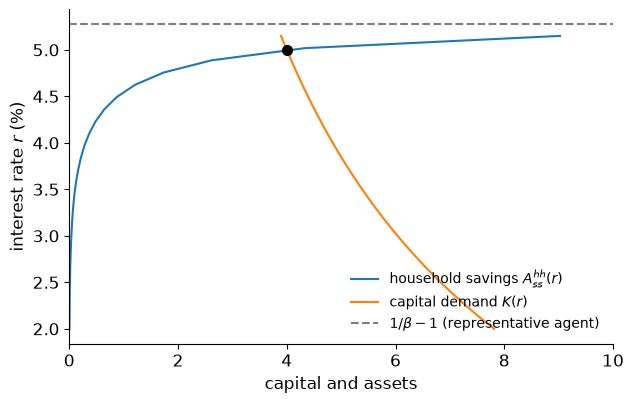

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(A_supply, 100*r_vec, label='household savings $A^{hh}_{ss}(r)$')
ax.plot(K_demand, 100*r_vec, label='capital demand $K(r)$')
ax.axhline(100*(1/par.beta-1), ls='--', color='black', alpha=0.5, label='$1/\\beta-1$ (representative agent)')
ax.plot(K_ss, 100*r_ss, 'o', color='black', ms=7)
ax.set_xlim(0, 10)
ax.set_xlabel('capital and assets')
ax.set_ylabel('interest rate $r$ (%)')
ax.legend(frameon=False, fontsize=10, loc='lower right')
fig.tight_layout()
fig.savefig('figs/notes/market_clearing.pdf')
fig.savefig('figs/notes/market_clearing.png', dpi=100)
plt.show()

## Household Jacobians with the fake-news shift

In [7]:
def jacobian_hh(price, par):
    """Jacobian of A_hh w.r.t. r or w: one backward pass for a shock at T-1, shifted, then T forward passes."""

    r_vec = np.full(T, r_ss)
    w_vec = np.full(T, w_ss)
    if price == 'r':
        r_vec[-1] += h
    else:
        w_vec[-1] += h
    _, _, a_last = get_impulse_response(vbeg_a_ss, D_ss, r_vec, w_vec, par)

    a_i_last, a_pi_last = get_lottery(a_last, par.a_grid)
    a_i_ss, a_pi_ss = get_lottery(np.broadcast_to(a_blank, (T,)+a_blank.shape), par.a_grid)

    J = np.zeros((T, T))
    for s in range(T):

        # a. policies for a shock at s: shifted before s, steady state after
        a_path = np.broadcast_to(a_blank, (T,)+a_blank.shape).copy()
        a_path[:s+1] = a_last[T-1-s:]
        a_i, a_pi = a_i_ss.copy(), a_pi_ss.copy()
        a_i[:s+1] = a_i_last[T-1-s:]
        a_pi[:s+1] = a_pi_last[T-1-s:]

        # b. forward and aggregate
        D_trans = forward_iteration_trans(D_ss, par.z_trans, a_i, a_pi, T)
        J[:, s] = (np.sum(D_trans*a_path, axis=(1,2)) - A_blank)/h

    return J

# a blank transition, so that numerical errors cancel
_, A_blank, a_blank_trans = get_impulse_response(vbeg_a_ss, D_ss, np.full(T, r_ss), np.full(T, w_ss), par)
a_blank = a_blank_trans[0]

J_r = jacobian_hh('r', par)
J_w = jacobian_hh('w', par)

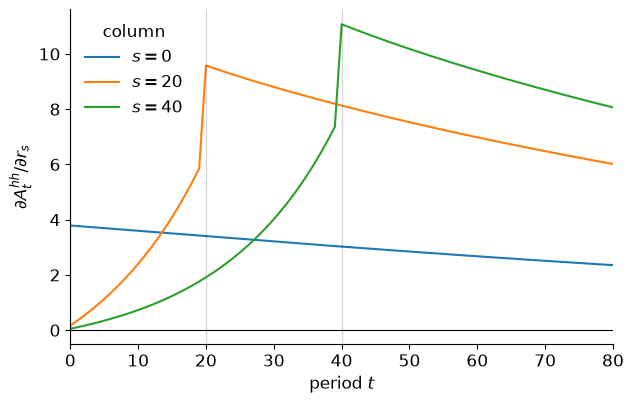

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for s in [0, 20, 40]:
    ax.plot(J_r[:, s], label=f'$s={s}$')
    ax.axvline(s, color='black', alpha=0.15, lw=1)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlim(0, 80)
ax.set_xlabel('period $t$')
ax.set_ylabel('$\\partial A^{hh}_t/\\partial r_s$')
ax.legend(frameon=False, title='column')
fig.tight_layout()
fig.savefig('figs/notes/jacobian.pdf')
fig.savefig('figs/notes/jacobian.png', dpi=100)
plt.show()

## Transitions in general equilibrium

In [9]:
dw_dK = np.zeros((T, T))
dr_dK = np.zeros((T, T))
dw_dK[1:, :-1] = np.eye(T-1)*(1-par.alpha)*par.alpha*par.Gamma*K_ss**(par.alpha-1)
dr_dK[1:, :-1] = np.eye(T-1)*par.alpha*(par.alpha-1)*par.Gamma*K_ss**(par.alpha-2)
dr_dGamma = np.eye(T)*par.alpha*K_ss**(par.alpha-1)
dw_dGamma = np.eye(T)*(1-par.alpha)*K_ss**par.alpha

H_K = J_w @ dw_dK + J_r @ dr_dK - np.eye(T)
H_Gamma = J_w @ dw_dGamma + J_r @ dr_dGamma
G = -np.linalg.solve(H_K, H_Gamma)

def transition(Gamma_path, K_guess, vbeg_a_term, tol=1e-10):
    """Newton on asset market clearing with the steady-state Jacobian."""

    K = K_guess.copy()
    for it in range(50):
        r, w, Y = firm(K, Gamma_path, K_ss, par)
        C, A, _ = get_impulse_response(vbeg_a_term, D_ss, r, w, par)
        error = np.max(np.abs(A-K))
        if error < tol:
            print(f'converged in {it} iterations')
            return K, C, r, w
        K = K - np.linalg.solve(H_K, A-K)

In [10]:
# a. transitory TFP shocks, small and large
rho = 0.9
paths = {}
for sigma_shock in [0.02, 0.2]:
    dGamma = sigma_shock*rho**np.arange(T)
    K_nonlinear, _, _, _ = transition(par.Gamma+dGamma, np.full(T, K_ss), vbeg_a_ss)
    paths[sigma_shock] = (K_nonlinear-K_ss, G @ dGamma)

# b. permanent TFP increase of 5 percent
Gamma_new = 1.05*par.Gamma

def asset_market_K(K, Gamma):
    """Excess savings in the steady state with capital K."""

    r = par.alpha*Gamma*K**(par.alpha-1) - par.delta
    w = (1-par.alpha)*Gamma*K**par.alpha
    return household_ss(r, w, par)[0] - K

K_ss_new = brentq(asset_market_K, 1.05*K_ss, 1.2*K_ss, args=(Gamma_new,))
r_ss_new = par.alpha*Gamma_new*K_ss_new**(par.alpha-1) - par.delta
w_ss_new = (1-par.alpha)*Gamma_new*K_ss_new**par.alpha
_, C_ss_new, _, _, _, vbeg_a_ss_new = household_ss(r_ss_new, w_ss_new, par)
K_perm, C_perm, r_perm, w_perm = transition(np.full(T, Gamma_new), np.full(T, K_ss_new), vbeg_a_ss_new)

print(f'K_ss: {K_ss:.3f} -> {K_ss_new:.3f}, r_ss: {r_ss:.4f} -> {r_ss_new:.4f}')

converged in 5 iterations


converged in 9 iterations


converged in 5 iterations
K_ss: 4.000 -> 4.304, r_ss: 0.0500 -> 0.0500


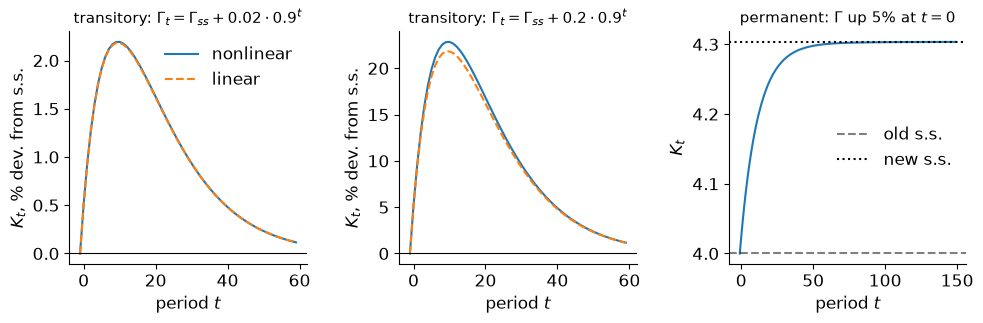

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3.4))
t_plot = np.arange(-1, 60)

for ax, sigma_shock in zip(axs[:2], [0.02, 0.2]):
    dK_nonlinear, dK_linear = paths[sigma_shock]
    ax.plot(t_plot, 100*np.insert(dK_nonlinear[:59+1], 0, 0)/K_ss, label='nonlinear')
    ax.plot(t_plot, 100*np.insert(dK_linear[:59+1], 0, 0)/K_ss, '--', label='linear')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'transitory: $\\Gamma_t=\\Gamma_{{ss}}+{sigma_shock}\\cdot{rho}^t$', fontsize=11)
    ax.set_xlabel('period $t$')
    ax.set_ylabel('$K_t$, % dev. from s.s.')
axs[0].legend(frameon=False)

ax = axs[2]
ax.plot(np.arange(-1, 150), np.insert(K_perm[:150], 0, K_ss))
ax.axhline(K_ss, ls='--', color='black', alpha=0.5, label='old s.s.')
ax.axhline(K_ss_new, ls=':', color='black', label='new s.s.')
ax.set_title('permanent: $\\Gamma$ up 5% at $t=0$', fontsize=11)
ax.set_xlabel('period $t$')
ax.set_ylabel('$K_t$')
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig('figs/notes/transitions.pdf')
fig.savefig('figs/notes/transitions.png', dpi=100)
plt.show()